# Influencer Marketing Analytics
### Predicting High-Engagement YouTube Campaigns for Marketing Investment Optimisation

**Adithya Ajay** · CB.SC.U4CSE23102 · CSE-B · Domain: Social Media Marketing

**Business problem.** Brands mostly choose YouTube influencers by subscriber count. This study
checks whether that works, and which characteristics a marketer can see *before* investing
actually predict high audience engagement.

**Outline**
1. Load the raw data
2. Cleaning, with every dropped row counted
3. Target variable
4. Feature engineering
5. Final dataset
6. Exploratory data analysis
7. Classification models and evaluation
8. Business insights and recommendations

## 1. Load the raw data

All data was collected by me for this study. Nothing was downloaded from Kaggle, UCI or any
dataset repository.

| File | What it is |
| --- | --- |
| `data/raw/youtube_api.csv` | Up to 150 most recent uploads per channel, collected with the YouTube Data API v3 on 10–11 Sep 2026 |
| `data/raw/youtube_api_deep.csv` | Older long-form videos for 21 channels whose recent uploads were almost all Shorts |
| `data/raw/video_language.csv` | Each video's declared audio language, fetched separately and joined on `id` |
| `data/channel_list.csv` | The sampling frame: 90 hand-picked channels plus 60 found through API search to balance subscriber tiers |

Collection started on Apify as proposed, but the chosen actor caps Free Plan accounts at 10 rows
per run (see `report/data_collection_notes.md`), so the official API was used instead.
The notebook never edits the raw files: every change below happens in memory and is saved to `data/processed/`. Before submission, email addresses and phone numbers that creators had posted in descriptions were masked in the raw files by `scripts/anonymize_raw.py`. The masks keep the text length, so no derived feature changes.

In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
(ROOT / "report").mkdir(exist_ok=True)

# Analysis choices. Each one is explained where it is applied.
LONG_FORM_ONLY = True          # drop Shorts (<= 180 s)
MIN_VIEWS = 1_000              # engagement rate is unstable on tiny denominators
MIN_AGE_DAYS = 30              # younger videos are still accumulating views
MIN_PRIOR_VIDEOS = 5           # history needed for channel_prior_engagement
HIGH_ENGAGEMENT_PCTL = 0.70    # top 30% of engagement rate = "high engagement"

In [2]:
main = pd.read_csv(RAW / "youtube_api.csv")
deep = pd.read_csv(RAW / "youtube_api_deep.csv")
raw = pd.concat([main, deep.drop(columns="defaultAudioLanguage")], ignore_index=True)
channels = pd.read_csv(ROOT / "data" / "channel_list.csv")
language = pd.concat([pd.read_csv(RAW / "video_language.csv", dtype=str),
                      deep[["id", "defaultAudioLanguage"]].astype(str).replace("nan", "")],
                     ignore_index=True)

print(f"raw videos        {len(raw):,}  ({len(main):,} main + {len(deep):,} long-form top-up)")
print(f"channels in raw   {raw.channelHandle.nunique()}")
print(f"sampling frame    {len(channels)} channels, {channels.niche.nunique()} niches")
raw.head(3)

raw videos        22,807  (22,442 main + 365 long-form top-up)
channels in raw   151
sampling frame    150 channels, 10 niches


,id,title,description,duration,views,likes,comments,publishDate,category,keywords,channelName,channelHandle,channelId,subscriberCount,channelVideoCount,madeForKids,niche,type,url,collectedAt
0,Od6M0AXpcxQ,iPhone 18 Pro/Duo Impressions: Mogged,The first folding iPhone Duo and iPhone 18 Pro...,1034.0,3724890.0,153250.0,12098.0,2026-09-10T07:29:55Z,Science & Technology,iPhone Duo|iPhone 18 Pro|MKBHD,Marques Brownlee,@mkbhd,UCBJycsmduvYEL83R_U4JriQ,21200000,1849,False,tech,video,https://www.youtube.com/watch?v=Od6M0AXpcxQ,NaN
1,R6yNUnRXZ64,iPhone Duo is here,What to know about iPhone Duo,70.0,822823.0,62075.0,1580.0,2026-09-10T07:02:22Z,Science & Technology,NaN,Marques Brownlee,@mkbhd,UCBJycsmduvYEL83R_U4JriQ,21200000,1849,False,tech,video,https://www.youtube.com/watch?v=R6yNUnRXZ64,NaN
2,uJdjKOBikTE,This iPhone Duo Animation 👀,NaN,20.0,3466003.0,92974.0,3302.0,2026-09-09T22:14:37Z,Science & Technology,NaN,Marques Brownlee,@mkbhd,UCBJycsmduvYEL83R_U4JriQ,21200000,1849,False,tech,video,https://www.youtube.com/watch?v=uJdjKOBikTE,NaN


## 2. Cleaning

Every step records how many rows it removed and why. That table is saved to
`report/preprocessing_steps.csv` for the report.

In [3]:
steps = []

def log_step(name, before, after, reason):
    steps.append({"step": name, "rows_before": len(before), "rows_after": len(after),
                  "dropped": len(before) - len(after), "reason": reason})
    print(f"{name:<44} {len(before):>7,} -> {len(after):>7,}   (-{len(before) - len(after):,})")
    return after.copy()

### 2.1 Sampling frame and duplicates

The raw file still holds 150 videos from `@minale`. That handle resolved to an unrelated
4,900-subscriber channel instead of the intended creator, so it was removed from the sampling
frame. Keeping only channels in the frame drops those rows.

In [4]:
df = raw.copy()
df = log_step("1. keep channels in sampling frame", df,
              df[df.channelHandle.isin(channels.channel_handle)],
              "handle resolved to the wrong channel (@minale)")
df = log_step("2. drop duplicate video ids", df, df.drop_duplicates("id"),
              "same video collected twice")

1. keep channels in sampling frame            22,807 ->  22,657   (-150)
2. drop duplicate video ids                   22,657 ->  22,657   (-0)


### 2.2 Non-English channels

The API's `relevanceLanguage=en` setting only ranks results; it doesn't filter them, so a few
Malayalam, Hindi and Telugu channels got in through search. Engagement norms differ by market,
and title features like character count mean something different in other scripts.

**Rule:** drop a channel if at least 5 of its videos declare an audio language and fewer than half
of those are English, **or** if most of its titles are in a non-Latin script. `zxx` means
"no linguistic content" and is not counted as a declaration.

In [5]:
df = df.merge(language[["id", "defaultAudioLanguage"]], on="id", how="left")
lang = df.defaultAudioLanguage.fillna("").str.lower()
df["lang_declared"] = (lang != "") & (lang != "zxx")
df["lang_en"] = lang.str.startswith("en")

def mostly_non_latin(title):
    letters = [c for c in str(title) if c.isalpha()]
    if not letters:
        return False
    other = sum(not unicodedata.name(c, "").startswith("LATIN") for c in letters)
    return other / len(letters) > 0.5

df["non_latin_title"] = df.title.map(mostly_non_latin)
ch_lang = df.groupby("channelHandle").agg(declared=("lang_declared", "sum"),
                                          english=("lang_en", "sum"),
                                          non_latin_share=("non_latin_title", "mean"))
ch_lang["english_share"] = ch_lang.english / ch_lang.declared.where(ch_lang.declared > 0)
non_english = ch_lang[((ch_lang.declared >= 5) & (ch_lang.english_share < 0.5))
                      | (ch_lang.non_latin_share > 0.5)]
display(non_english.round(2))

df = log_step("3. drop non-English channels", df,
              df[~df.channelHandle.isin(non_english.index)],
              "declared audio language mostly non-English")

,declared,english,non_latin_share,english_share
channelHandle,,,,
@jrstudiomalayalam,150,0,0.41,0.00
@mrsyumtum,32,4,0.00,0.12
@parulmahaajan1,150,0,0.00,0.00
@reshmifit-od3nw,9,3,0.00,0.33


3. drop non-English channels                  22,657 ->  22,057   (-600)


### 2.3 Missing values

A missing `likes` value means the creator hid the like count. A missing `comments` value means
comments are disabled, which YouTube forces on made-for-kids videos. Either way engagement rate
can't be calculated, so those rows go.

Missing `description` or `keywords` is information, not an error: the creator left them empty.
Those are kept and become length 0 / 0 tags.

In [6]:
print(df[["views", "likes", "comments", "duration", "description", "keywords"]].isna().sum())
df = log_step("4. drop missing views/likes/comments", df,
              df.dropna(subset=["views", "likes", "comments", "duration"]),
              "likes hidden or comments disabled")

views             5
likes           349
comments         44
duration         10
description    2908
keywords       6997
dtype: int64
4. drop missing views/likes/comments          22,057 ->  21,671   (-386)


### 2.4 Low views and very recent videos

- **Under 1,000 views:** with a tiny denominator, a handful of likes swings the rate wildly.
- **Under 30 days old:** views keep arriving after likes and comments level off, so a new
  video's rate is still drifting.

Statistics are a snapshot taken at collection time. Age is therefore measured from the day each
video was collected (seed channels on 10 Sep; search-found channels and the long-form top-up on
11 Sep), not from the day this notebook is run. That keeps the results reproducible.

In [7]:
found_by_search = channels.set_index("channel_handle").source.str.startswith("api_search")
first_pass_date = df.channelHandle.map(found_by_search.map({False: "2026-09-10", True: "2026-09-11"}))
df["collected_at"] = pd.to_datetime(df.collectedAt.fillna(first_pass_date), utc=True)
df["published_at"] = pd.to_datetime(df.publishDate, utc=True)
df["video_age_days"] = (df.collected_at - df.published_at).dt.total_seconds() / 86400

df = log_step("5. drop videos under 1,000 views", df, df[df.views >= MIN_VIEWS],
              "engagement rate too noisy on small denominators")
df = log_step("6. drop videos under 30 days old", df, df[df.video_age_days >= MIN_AGE_DAYS],
              "still accumulating views")

5. drop videos under 1,000 views              21,671 ->  21,406   (-265)
6. drop videos under 30 days old              21,406 ->  19,350   (-2,056)


### 2.5 Shorts

**Decision: analyse long-form videos only.** Brands mostly buy influencer sponsorships as segments
inside long-form videos, and that is the campaign type this study is about. Shorts are also measured
differently: since March 2025 YouTube counts every Shorts play and replay as a view, so
`(likes + comments) / views` doesn't mean the same thing for both formats.

The API has no Shorts flag. A video is treated as a Short if it runs 180 seconds or less,
which is YouTube's current Shorts length limit.

In [8]:
df["is_short"] = df.duration <= 180
print(df.is_short.map({True: "short", False: "long-form"}).value_counts())
if LONG_FORM_ONLY:
    df = log_step("7. drop Shorts (<= 180 s)", df, df[~df.is_short],
                  "different format; views counted differently")

is_short
long-form    12597
short         6753
Name: count, dtype: int64
7. drop Shorts (<= 180 s)                     19,350 ->  12,597   (-6,753)


## 3. Target variable

$$\text{engagement rate} = \frac{\text{likes} + \text{comments}}{\text{views}}$$

A video is **high engagement** (`1`) if its engagement rate is in the top 30% of the cleaned
dataset, and `0` otherwise.

> **Leakage rule.** The target is calculated from `likes`, `comments` and `views`, so **none of
> those three can be used as a predictor.** A model fed them would reach about 99% accuracy by
> reading the answer back, and would be useless in practice: a marketer deciding whether to invest
> can't know a future video's likes.

In [9]:
df["engagement_rate"] = (df.likes + df.comments) / df.views
df = log_step("8. drop impossible engagement rate (> 1)", df, df[df.engagement_rate <= 1],
              "more likes + comments than views - data error")

threshold = df.engagement_rate.quantile(HIGH_ENGAGEMENT_PCTL)
df["high_engagement"] = (df.engagement_rate >= threshold).astype(int)

print(f"high-engagement threshold (70th percentile): {threshold:.4f} = {threshold:.2%}")
print(df.high_engagement.value_counts(normalize=True).rename({0: "normal", 1: "high"}).round(3))
df.engagement_rate.describe().round(4)

8. drop impossible engagement rate (> 1)      12,597 ->  12,597   (-0)
high-engagement threshold (70th percentile): 0.0452 = 4.52%
high_engagement
normal    0.7
high      0.3
Name: proportion, dtype: float64


count    12597.0000
mean         0.0388
std          0.0205
min          0.0000
25%          0.0250
50%          0.0350
75%          0.0485
max          0.3921
Name: engagement_rate, dtype: float64

## 4. Feature engineering

Every feature has to be **knowable before a brand invests**: facts about the channel, and
properties of the content that a creator decides before publishing.

In [10]:
# channel
df["subscriber_count"] = df.subscriberCount
df["log_subscribers"] = np.log1p(df.subscriber_count)
df["subscriber_tier"] = pd.cut(df.subscriber_count, [0, 200_000, 1_000_000, 5_000_000, np.inf],
                               labels=["<200K", "200K-1M", "1M-5M", "5M+"], right=False)
df["log_channel_video_count"] = np.log1p(df.channelVideoCount)

# content
df["duration_seconds"] = df.duration
df["log_duration"] = np.log1p(df.duration)
df["duration_bucket"] = pd.cut(df.duration, [0, 180, 480, 900, 1200, 1800, np.inf],
                               labels=["<=3 min", "3-8 min", "8-15 min", "15-20 min",
                                       "20-30 min", "30+ min"])
df["keywords"] = df.keywords.fillna("")
df["tag_count"] = df.keywords.map(lambda k: len(k.split("|")) if k else 0)
df["made_for_kids"] = df.madeForKids.astype(str).str.lower().eq("true").astype(int)

# title
EMOJI = "[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF]"
t = df.title.fillna("")
df["title_length_chars"] = t.str.len()
df["title_word_count"] = t.str.split().str.len()
df["has_number_in_title"] = t.str.contains(r"\d").astype(int)
df["has_question_mark"] = t.str.contains(r"\?").astype(int)
df["has_exclamation"] = t.str.contains("!").astype(int)
df["caps_word_count"] = t.map(lambda s: sum(w.isupper() for w in re.findall(r"[A-Za-z]{2,}", s)))
df["emoji_count"] = t.str.count(EMOJI)

# description
d = df.description.fillna("")
df["description_length"] = d.str.len()
df["description_link_count"] = d.str.count(r"https?://")
df["has_hashtags"] = d.str.contains(r"#\w+").astype(int)
SPONSOR = r"\b(?:sponsor(?:ed)?|use (?:my )?code|promo code|discount code|affiliate|paid partnership)\b"
df["has_sponsor_mention"] = d.str.contains(SPONSOR, case=False, regex=True).astype(int)

# timing (UTC - channels are global, so there is no single local time zone)
df["upload_day_of_week"] = df.published_at.dt.day_name()
df["upload_hour_utc"] = df.published_at.dt.hour
df["upload_daypart_utc"] = pd.cut(df.upload_hour_utc, [-1, 5, 11, 17, 23],
                                  labels=["00-05", "06-11", "12-17", "18-23"]).astype(str)
df["is_weekend"] = (df.published_at.dt.dayofweek >= 5).astype(int)

print(f"sponsor mention in description: {df.has_sponsor_mention.mean():.1%} of videos")

sponsor mention in description: 30.6% of videos


### 4.1 Channel engagement history, built without leakage

A marketer would naturally check how a creator's *past* videos performed, and this is usually
the strongest predictor. It's also the easiest feature to get wrong.

- **Wrong:** the channel's average engagement rate over all its videos. That includes the video
  being predicted, so the answer leaks into the feature.
- **Still wrong:** leave-one-out (every *other* video). That includes videos published *after* the
  one being predicted, which no marketer could have seen at decision time.
- **Used here:** the average engagement rate of the channel's videos published **strictly
  earlier**. A video needs at least 5 earlier videos, otherwise it has no reliable history.

The check below recomputes the value by hand for one video to prove it only uses earlier videos.

In [11]:
df = df.sort_values(["channelHandle", "published_at"]).reset_index(drop=True)
by_channel = df.groupby("channelHandle").engagement_rate
prior_n = by_channel.cumcount()                            # number of earlier videos
prior_sum = by_channel.cumsum() - df.engagement_rate       # sum over earlier videos only
df["channel_prior_videos"] = prior_n
df["channel_prior_engagement"] = (prior_sum / prior_n.replace(0, np.nan)).where(
    prior_n >= MIN_PRIOR_VIDEOS)

# hand check on one video
one = df[df.channelHandle == df.channelHandle.iloc[0]].reset_index(drop=True)
k = MIN_PRIOR_VIDEOS + 3
by_hand = one.engagement_rate.iloc[:k].mean()              # videos 0..k-1, strictly before k
assert np.isclose(one.channel_prior_engagement.iloc[k], by_hand)
assert not np.isclose(one.channel_prior_engagement.iloc[k], one.engagement_rate.iloc[:k + 1].mean())
print(f"check passed: {one.channelHandle.iloc[0]} video {k} uses only its {k} earlier videos")

df = log_step("9. drop videos with < 5 earlier videos", df,
              df[df.channel_prior_engagement.notna()],
              "no engagement history for the channel yet")

check passed: @1millionwithin5years video 8 uses only its 8 earlier videos
9. drop videos with < 5 earlier videos        12,597 ->  11,877   (-720)


## 5. Final dataset

Three last adjustments before fixing the predictor list:

- **YouTube category is dropped.** It mostly repeats the niche (a gaming channel files its videos
  under Gaming), and two overlapping sets of dummy variables let logistic regression build large
  opposite-signed coefficients that cancel each other out. The table below shows how much of each
  niche falls into a single category.
- **`made_for_kids` is dropped.** Every remaining video has the same value, because step 4
  already removed made-for-kids videos (their comments are disabled).
- **`title_word_count` is dropped.** It is almost the same measurement as `title_length_chars`,
  and two near-duplicate predictors make logistic regression coefficients unstable.

In [12]:
overlap = pd.crosstab(df.niche, df.category, normalize="index")
display(pd.DataFrame({"main_category": overlap.idxmax(axis=1),
                      "share_of_niche": overlap.max(axis=1).round(2)}))

r_title = df.title_word_count.corr(df.title_length_chars)
print(f"made_for_kids = 1 for {df.made_for_kids.sum()} of {len(df):,} videos")
print(f"title_word_count vs title_length_chars: r = {r_title:.2f}")

,main_category,share_of_niche
niche,,
beauty,Howto & Style,0.59
education,Education,0.59
fashion,Howto & Style,0.53
finance,Education,0.68
fitness,Howto & Style,0.39
food,Howto & Style,0.44
gaming,Gaming,0.97
lifestyle,People & Blogs,0.42
tech,Science & Technology,0.79


made_for_kids = 1 for 0 of 11,877 videos
title_word_count vs title_length_chars: r = 0.92


In [13]:
predictors = {
    "channel": ["log_subscribers", "log_channel_video_count", "niche", "channel_prior_engagement"],
    "content": ["log_duration", "tag_count"],
    "title": ["title_length_chars", "has_number_in_title", "has_question_mark",
              "has_exclamation", "caps_word_count", "emoji_count"],
    "description": ["description_length", "description_link_count", "has_hashtags",
                    "has_sponsor_mention"],
    "timing": ["upload_day_of_week", "upload_daypart_utc", "is_weekend", "video_age_days"],
}

rows = [(f, grp, "predictor", "known before investing") for grp, fs in predictors.items() for f in fs]
rows += [("subscriber_tier", "channel", "EDA only", "banded copy of log_subscribers"),
         ("upload_hour_utc", "timing", "EDA only", "grouped into upload_daypart_utc for the model"),
         ("made_for_kids", "content", "dropped", f"constant: {df.made_for_kids.sum()} videos are 1"),
         ("title_word_count", "title", "dropped", f"r = {r_title:.2f} with title_length_chars"),
         ("category", "content", "dropped", "largely repeats niche - see overlap table"),
         ("views, likes, comments", "outcome", "NOT USED", "target is built from these - leakage"),
         ("engagement_rate", "outcome", "NOT USED", "the target before thresholding"),
         ("high_engagement", "target", "target", "1 = top 30% engagement rate")]
dictionary = pd.DataFrame(rows, columns=["column", "group", "role", "why"])
display(dictionary)

,column,group,role,why
0,log_subscribers,channel,predictor,known before investing
1,log_channel_video_count,channel,predictor,known before investing
2,niche,channel,predictor,known before investing
3,channel_prior_engagement,channel,predictor,known before investing
4,log_duration,content,predictor,known before investing
5,tag_count,content,predictor,known before investing
6,title_length_chars,title,predictor,known before investing
7,has_number_in_title,title,predictor,known before investing
8,has_question_mark,title,predictor,known before investing
9,has_exclamation,title,predictor,known before investing


In [14]:
feature_cols = [f for fs in predictors.values() for f in fs]
id_cols = ["id", "url", "title", "channelHandle", "channelName", "published_at"]
extra = ["subscriber_count", "subscriber_tier", "category", "duration_seconds", "duration_bucket",
         "upload_hour_utc", "title_word_count", "channel_prior_videos"]
outcome_cols = ["views", "likes", "comments", "engagement_rate", "high_engagement"]
clean = df[id_cols + feature_cols + extra + outcome_cols].copy()
clean.to_csv(PROCESSED / "videos_clean.csv", index=False)

steps_df = pd.DataFrame(steps)
steps_df.to_csv(ROOT / "report" / "preprocessing_steps.csv", index=False)
display(steps_df)

print(f"\nfinal dataset: {len(clean):,} videos, {clean.channelHandle.nunique()} channels, "
      f"{len(feature_cols)} predictors")
print(f"kept {len(clean) / steps_df.rows_before.iloc[0]:.1%} of raw rows")
clean.groupby("subscriber_tier", observed=True).agg(channels=("channelHandle", "nunique"),
                                                     videos=("id", "size"),
                                                     high_share=("high_engagement", "mean")).round(3)

,step,rows_before,rows_after,dropped,reason
0,1. keep channels in sampling frame,22807,22657,150,handle resolved to the wrong channel (@minale)
1,2. drop duplicate video ids,22657,22657,0,same video collected twice
2,3. drop non-English channels,22657,22057,600,declared audio language mostly non-English
3,4. drop missing views/likes/comments,22057,21671,386,likes hidden or comments disabled
4,"5. drop videos under 1,000 views",21671,21406,265,engagement rate too noisy on small denominators
5,6. drop videos under 30 days old,21406,19350,2056,still accumulating views
6,7. drop Shorts (<= 180 s),19350,12597,6753,different format; views counted differently
7,8. drop impossible engagement rate (> 1),12597,12597,0,more likes + comments than views - data error
8,9. drop videos with < 5 earlier videos,12597,11877,720,no engagement history for the channel yet



final dataset: 11,877 videos, 143 channels, 20 predictors
kept 52.1% of raw rows


,channels,videos,high_share
subscriber_tier,,,
<200K,26,1867,0.258
200K-1M,32,2336,0.325
1M-5M,41,4151,0.425
5M+,44,3523,0.165


## 6. Exploratory data analysis

Each chart is saved to `report/figures/` for the report, and the table printed under it holds
the exact numbers behind it.

In [15]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import NullFormatter, PercentFormatter

FIGURES = ROOT / "report" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Colour roles (validated reference palette, light mode)
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, RED, NEUTRAL, DEEMPH = "#2a78d6", "#eb6834", "#e34948", "#f0efec", "#c3c2b7"
RAMP = {100: "#cde2fb", 250: "#86b6ef", 400: "#3987e5", 500: "#256abf", 550: "#1c5cab",
        600: "#184f95", 700: "#0d366b"}
ORDINAL_4 = [RAMP[s] for s in (250, 400, 550, 700)]          # ordered tiers
ORDINAL_5 = [RAMP[s] for s in (250, 400, 500, 600, 700)]     # ordered duration bands
SEQUENTIAL = LinearSegmentedColormap.from_list("blue", [RAMP[s] for s in (100, 250, 400, 550, 700)])
DIVERGING = LinearSegmentedColormap.from_list("red_blue", [RED, NEUTRAL, BLUE])
PCT = PercentFormatter(1.0, decimals=0)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK_2, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "legend.frameon": False, "legend.labelcolor": INK_2,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

LABELS = {
    "engagement_rate": "engagement rate", "channel_prior_engagement": "channel history",
    "log_subscribers": "subscribers (log)", "log_channel_video_count": "channel uploads (log)",
    "log_duration": "duration (log)", "video_age_days": "video age", "tag_count": "tags",
    "title_length_chars": "title length", "caps_word_count": "CAPS words", "emoji_count": "emoji",
    "has_number_in_title": "number in title", "has_question_mark": "question mark",
    "has_exclamation": "exclamation mark", "description_length": "description length",
    "description_link_count": "description links", "has_hashtags": "hashtags",
    "has_sponsor_mention": "sponsor mention", "is_weekend": "weekend upload",
    "niche": "niche", "category_grouped": "YouTube category", "upload_day_of_week": "upload day",
    "upload_daypart_utc": "upload time of day",
}

def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png")
    plt.show()

### 6.1 How engagement is distributed

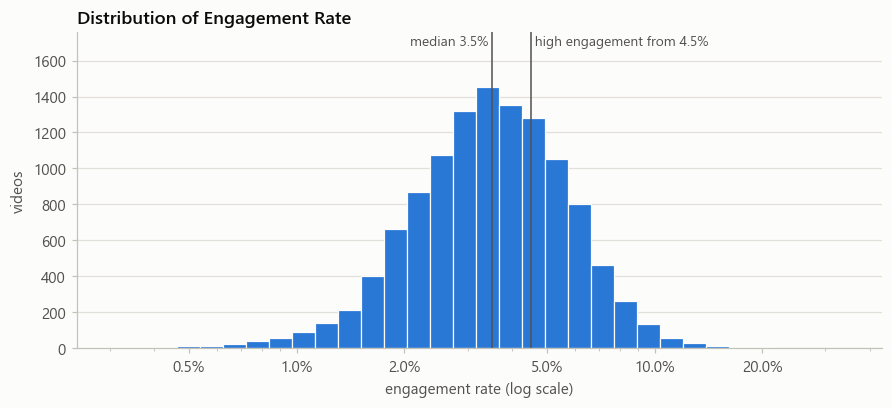

1 videos at 0% and 12 below 0.24% fall outside the log axis


,count,mean,std,min,10%,25%,50%,75%,90%,max
engagement_rate,11877.0,0.0389,0.0204,0.0,0.0184,0.0251,0.0351,0.0486,0.0636,0.3921


In [16]:
er = clean.engagement_rate
q1, med, q3 = er.quantile([0.25, 0.5, 0.75])
positive = er[er > 0]

fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
ax.hist(positive, bins=np.logspace(np.log10(positive.min()), np.log10(positive.max()), 60),
        color=BLUE, edgecolor=SURFACE, linewidth=0.8)
ax.set_xscale("log")
left = max(positive.quantile(0.001), 0.001)
ax.set_xticks([v for v in (0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2) if left <= v <= positive.max()])
ax.set_xlim(left, positive.max() * 1.1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.xaxis.set_minor_formatter(NullFormatter())
top = ax.get_ylim()[1] * 1.15
ax.set_ylim(top=top)
ax.axvline(med, color=INK_2, linewidth=1)
ax.text(med, top * 0.99, f"median {med:.1%} ", color=INK_2, fontsize=9, va="top", ha="right")
ax.axvline(threshold, color=INK_2, linewidth=1)
ax.text(threshold, top * 0.99, f" high engagement from {threshold:.1%}", color=INK_2, fontsize=9, va="top")
ax.yaxis.grid(True)
ax.set_xlabel("engagement rate (log scale)")
ax.set_ylabel("videos")
ax.set_title("Distribution of Engagement Rate")
save(fig, "01_engagement_distribution")

print(f"{(er == 0).sum()} videos at 0% and {(positive < left).sum()} below {left:.2%} fall outside the log axis")
er.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("engagement_rate").T.round(4)

**Reading.** Engagement is tightly clustered: half of all long-form videos land between 2.5% and 4.9%.
A creator who is consistently above the 4.5% high-engagement line is genuinely outperforming. Budget
discussions should use the rate rather than raw like counts, because the rate is comparable across
channel sizes.

### 6.2 Does channel size predict engagement? (headline question)

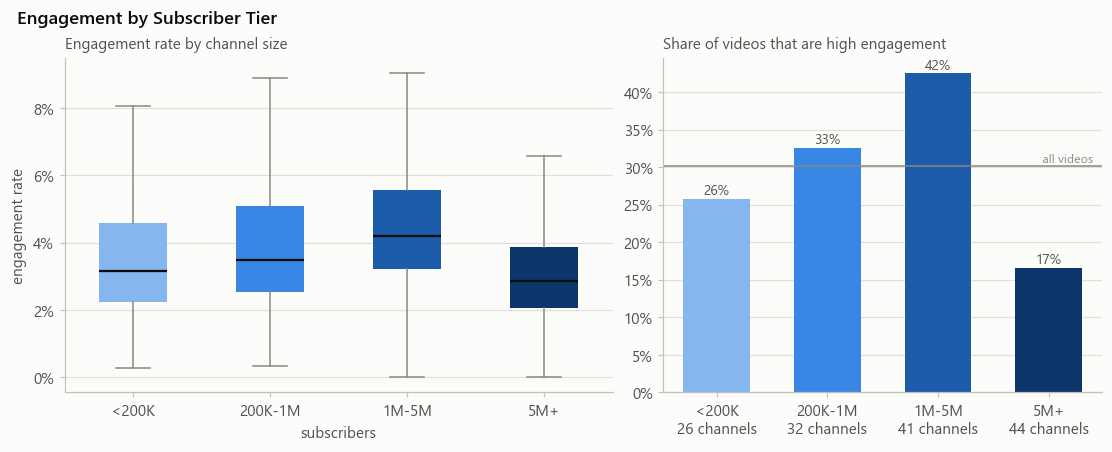

,channels,videos,median_engagement,high_share
subscriber_tier,,,,
<200K,26,1867,0.0317,0.2576
200K-1M,32,2336,0.0350,0.3253
1M-5M,41,4151,0.0419,0.4247
5M+,44,3523,0.0286,0.1652


In [17]:
tiers = ["<200K", "200K-1M", "1M-5M", "5M+"]
tier_table = (clean.groupby("subscriber_tier", observed=True)
              .agg(channels=("channelHandle", "nunique"), videos=("id", "size"),
                   median_engagement=("engagement_rate", "median"),
                   high_share=("high_engagement", "mean"))
              .reindex(tiers))
share = tier_table.high_share

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4), layout="constrained",
                             gridspec_kw={"width_ratios": [1.25, 1]})
bp = a1.boxplot([clean.loc[clean.subscriber_tier == t, "engagement_rate"] for t in tiers],
                widths=0.5, patch_artist=True, showfliers=False,
                medianprops=dict(color=INK, linewidth=1.5), whiskerprops=dict(color=MUTED),
                capprops=dict(color=MUTED), boxprops=dict(linewidth=0))
for patch, colour in zip(bp["boxes"], ORDINAL_4):
    patch.set_facecolor(colour)
a1.set_xticks(range(1, 5), tiers)
a1.yaxis.set_major_formatter(PCT)
a1.yaxis.grid(True)
a1.set_xlabel("subscribers")
a1.set_ylabel("engagement rate")
a1.set_title("Engagement rate by channel size", fontsize=10, fontweight="normal", color=INK_2)

x = np.arange(4)
a2.bar(x, share.values, width=0.6, color=ORDINAL_4)
for i, v in enumerate(share.values):
    a2.annotate(f"{v:.0%}", (i, v), xytext=(0, 3), textcoords="offset points",
                ha="center", color=INK_2, fontsize=9)
a2.axhline(clean.high_engagement.mean(), color=MUTED, linewidth=1)
a2.text(3.4, clean.high_engagement.mean(), " all videos", color=MUTED, fontsize=8, va="bottom", ha="right")
a2.set_xticks(x, [f"{t}\n{n} channels" for t, n in zip(tiers, tier_table.channels)])
a2.yaxis.set_major_formatter(PCT)
a2.yaxis.grid(True)
a2.set_title("Share of videos that are high engagement", fontsize=10, fontweight="normal", color=INK_2)

fig.suptitle("Engagement by Subscriber Tier", x=0.01, ha="left", fontsize=12, fontweight="semibold", color=INK)
save(fig, "02_engagement_by_subscriber_tier")
tier_table.round(4)

**Reading.** Subscriber count does not rank creators by engagement. The share of high-engagement videos
rises from 26% (under 200K) to 42% (1M–5M), then collapses to 17% for 5M+ channels, the tier brands
pay the most for. For engagement-led campaigns, 1M–5M creators offer the best odds; the biggest
channels buy reach, not response.

### 6.3 Engagement by niche

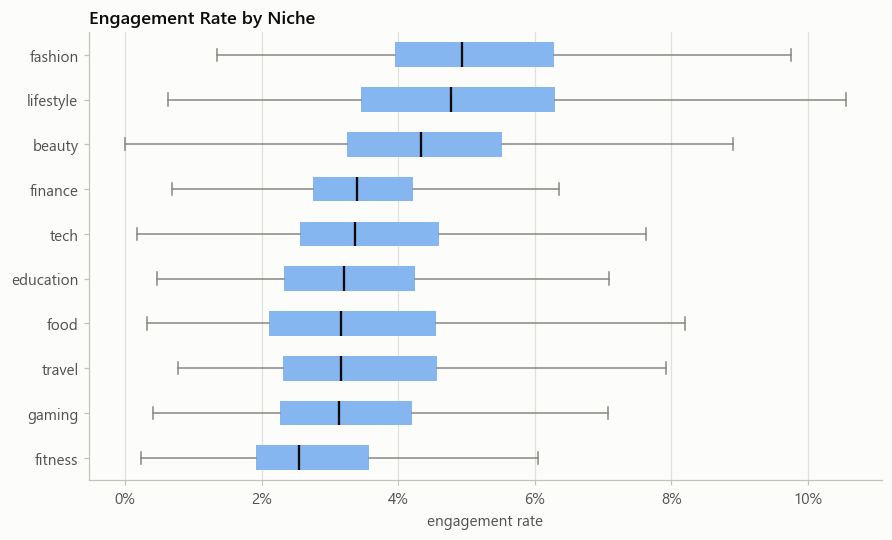

,channels,videos,median_engagement,high_share
niche,,,,
fashion,12,1047,0.0494,0.5950
lifestyle,14,1290,0.0478,0.5341
beauty,15,929,0.0434,0.4499
finance,15,1049,0.0340,0.1859
tech,15,1263,0.0336,0.2644
education,15,1314,0.0320,0.2131
food,13,947,0.0317,0.2555
travel,14,1404,0.0317,0.2585
gaming,15,1382,0.0313,0.2026


In [18]:
niche_table = (clean.groupby("niche")
               .agg(channels=("channelHandle", "nunique"), videos=("id", "size"),
                    median_engagement=("engagement_rate", "median"),
                    high_share=("high_engagement", "mean"))
               .sort_values("median_engagement"))
order = niche_table.index

fig, ax = plt.subplots(figsize=(8, 4.8), layout="constrained")
ax.boxplot([clean.loc[clean.niche == n, "engagement_rate"] for n in order], orientation="horizontal",
           widths=0.55, patch_artist=True, showfliers=False,
           medianprops=dict(color=INK, linewidth=1.5), whiskerprops=dict(color=MUTED),
           capprops=dict(color=MUTED), boxprops=dict(facecolor=RAMP[250], linewidth=0))
ax.set_yticks(range(1, len(order) + 1), order)
ax.xaxis.set_major_formatter(PCT)
ax.xaxis.grid(True)
ax.set_xlabel("engagement rate")
ax.set_title("Engagement Rate by Niche")
save(fig, "03_engagement_by_niche")
niche_table.sort_values("median_engagement", ascending=False).round(4)

**Reading.** Niche changes the odds several-fold: 60% of fashion and 53% of lifestyle videos are high
engagement, against 13% for fitness and 20% for gaming. Engagement targets need to be set per niche.
A 4.5% target is easy in fashion and unrealistic in fitness.

### 6.4 Which numeric features move with engagement?

Spearman correlation is used rather than Pearson because engagement rate, view counts and
description lengths are heavily skewed. Only correlations of at least 0.3 in size are labelled.

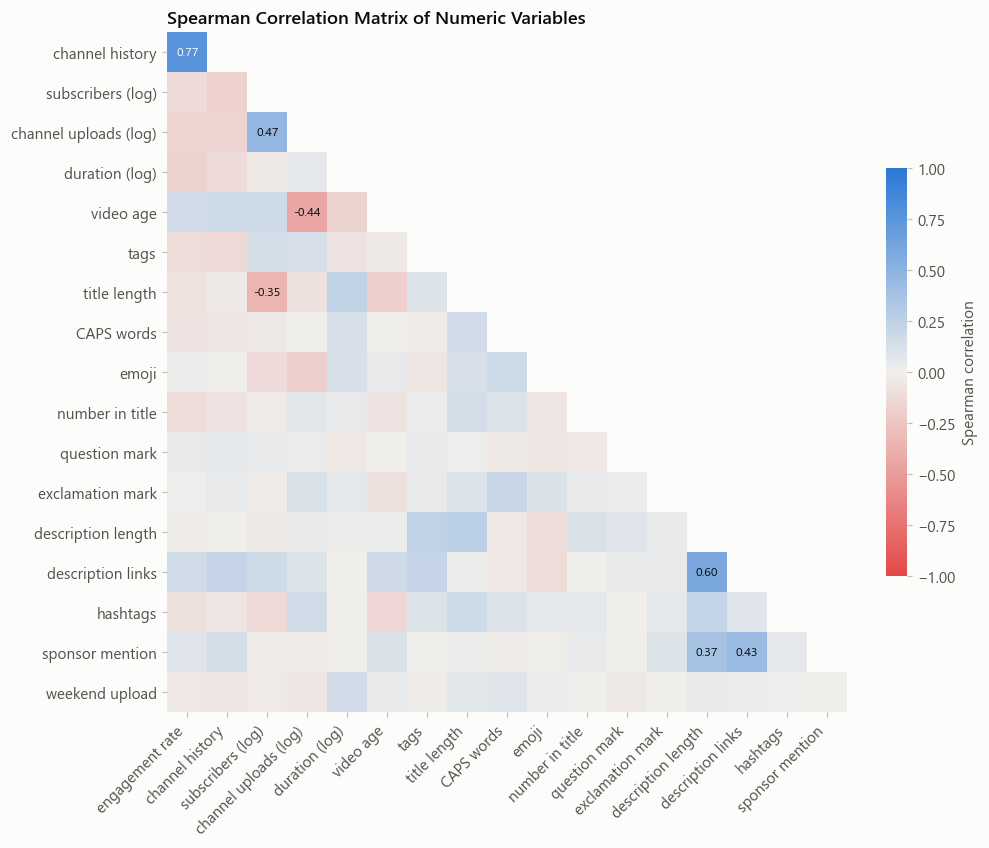

,spearman_with_engagement_rate
channel history,0.773
duration (log),-0.170
description links,0.160
channel uploads (log),-0.157
video age,0.155
subscribers (log),-0.120
number in title,-0.116
tags,-0.112
sponsor mention,0.091
hashtags,-0.089


In [19]:
corr_cols = ["engagement_rate", "channel_prior_engagement", "log_subscribers", "log_channel_video_count",
             "log_duration", "video_age_days", "tag_count", "title_length_chars", "caps_word_count",
             "emoji_count", "has_number_in_title", "has_question_mark", "has_exclamation",
             "description_length", "description_link_count", "has_hashtags", "has_sponsor_mention",
             "is_weekend"]
corr = clean[corr_cols].corr(method="spearman").rename(index=LABELS, columns=LABELS)
# lower triangle without the diagonal: body row i is compared with columns 0..i
body = corr.iloc[1:, :-1]
lower = body.mask(np.triu(np.ones(body.shape, dtype=bool), k=1))

fig, ax = plt.subplots(figsize=(9, 7.6), layout="constrained")
im = ax.imshow(lower, cmap=DIVERGING, vmin=-1, vmax=1)
for i in range(body.shape[0]):
    for j in range(i + 1):
        v = body.iat[i, j]
        if abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) >= 0.6 else INK)
ax.set_xticks(range(body.shape[1]), body.columns, rotation=45, ha="right")
ax.set_yticks(range(body.shape[0]), body.index)
for spine in ax.spines.values():
    spine.set_visible(False)
bar = fig.colorbar(im, ax=ax, shrink=0.6, label="Spearman correlation")
bar.outline.set_visible(False)

with_target = corr["engagement rate"].drop("engagement rate")
ranked = with_target.abs().sort_values(ascending=False)
ax.set_title("Spearman Correlation Matrix of Numeric Variables")
save(fig, "04_correlation_heatmap")
with_target.reindex(ranked.index).round(3).to_frame("spearman_with_engagement_rate")

**Reading.** A channel's past engagement tracks the next video's engagement closely (ρ = 0.77). Every
other single feature is weak (|ρ| ≤ 0.17), so no one title or description choice moves engagement much
on its own. The clearest pre-investment signal is how a creator's audience has responded before.

### 6.5 Video length

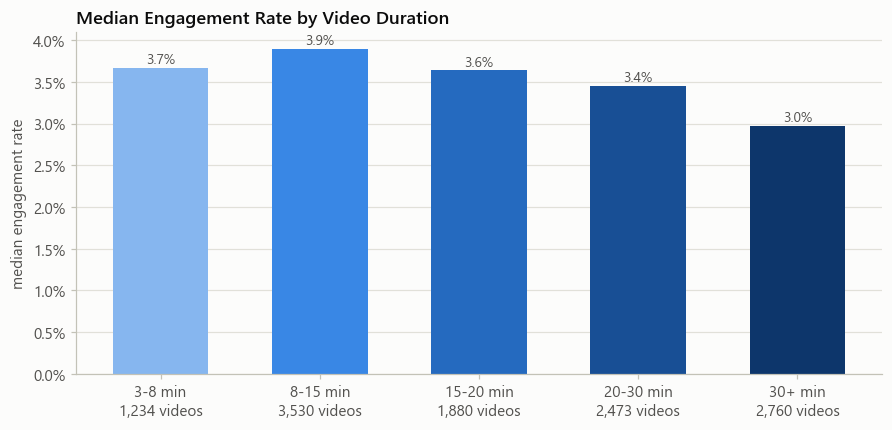

,videos,median_engagement,high_share
duration_bucket,,,
3-8 min,1234,0.0367,0.3404
8-15 min,3530,0.0390,0.3904
15-20 min,1880,0.0364,0.3223
20-30 min,2473,0.0345,0.2717
30+ min,2760,0.0298,0.1848


In [20]:
dur = (clean.groupby("duration_bucket", observed=True)
       .agg(videos=("id", "size"), median_engagement=("engagement_rate", "median"),
            high_share=("high_engagement", "mean")))
assert len(dur) <= len(ORDINAL_5)

fig, ax = plt.subplots(figsize=(8, 3.8), layout="constrained")
x = np.arange(len(dur))
ax.bar(x, dur.median_engagement, width=0.6, color=ORDINAL_5[:len(dur)])
for i, v in enumerate(dur.median_engagement):
    ax.annotate(f"{v:.1%}", (i, v), xytext=(0, 3), textcoords="offset points",
                ha="center", color=INK_2, fontsize=9)
ax.set_xticks(x, [f"{b}\n{n:,} videos" for b, n in zip(dur.index, dur.videos)])
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.yaxis.grid(True)
ax.set_ylabel("median engagement rate")
ax.set_title("Median Engagement Rate by Video Duration")
save(fig, "05_engagement_by_duration")
dur.round(4)

**Reading.** 8–15 minute videos engage best (median 3.9%, 39% high engagement), and engagement falls
steadily with length: 30+ minute videos reach only 3.0% (18% high). For a sponsored integration, a
mid-length video is the safer format.

### 6.6 Upload day and hour (UTC)

Cells with fewer than 30 videos are greyed out: a share based on a handful of videos is noise.

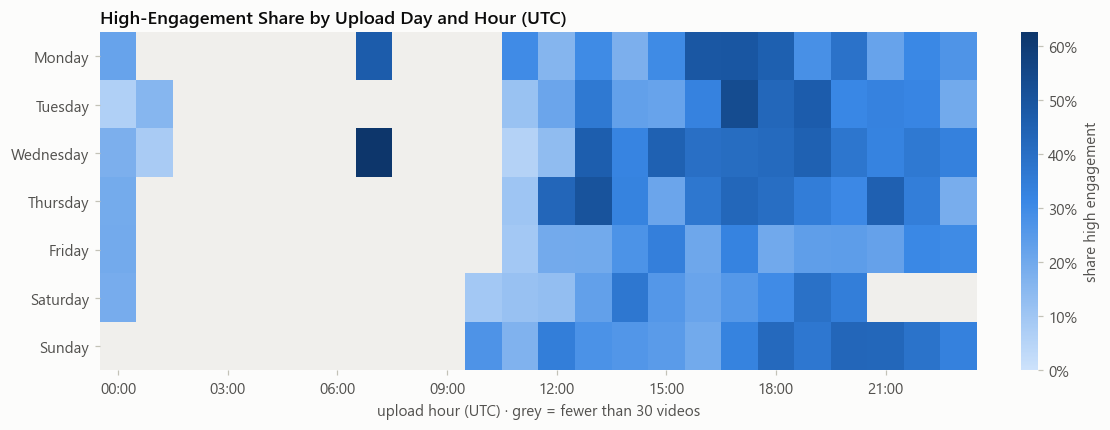

videos  high_share
by day               Monday       1593       0.343
                     Tuesday      1640       0.293
                     Wednesday    1675       0.350
                     Thursday     1852       0.336
                     Friday       1448       0.242
                     Saturday     1447       0.244
                     Sunday       2222       0.292
by time of day (UTC) 00-05         746       0.177
                     06-11        1141       0.174
                     12-17        6486       0.316
                     18-23        3504       0.345

In [21]:
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
slot = clean.groupby(["upload_day_of_week", "upload_hour_utc"]).high_engagement.agg(["mean", "size"])
share_grid = slot["mean"].unstack().reindex(index=days, columns=range(24))
n_grid = slot["size"].unstack().reindex(index=days, columns=range(24)).fillna(0)
shown = share_grid.where(n_grid >= 30)

fig, ax = plt.subplots(figsize=(10, 3.8), layout="constrained")
cmap = SEQUENTIAL.copy()
cmap.set_bad(NEUTRAL)
im = ax.imshow(shown, cmap=cmap, aspect="auto", vmin=0, vmax=max(0.6, np.nanmax(shown.values)))
ax.set_xticks(range(0, 24, 3), [f"{h:02d}:00" for h in range(0, 24, 3)])
ax.set_yticks(range(7), days)
for spine in ax.spines.values():
    spine.set_visible(False)
bar = fig.colorbar(im, ax=ax, label="share high engagement", format=PCT)
bar.outline.set_visible(False)
ax.set_xlabel("upload hour (UTC) · grey = fewer than 30 videos")
ax.set_title("High-Engagement Share by Upload Day and Hour (UTC)")
save(fig, "06_upload_timing_heatmap")

timing = pd.concat({
    "by day": clean.groupby("upload_day_of_week").high_engagement.agg(["size", "mean"]).reindex(days),
    "by time of day (UTC)": clean.groupby("upload_daypart_utc").high_engagement.agg(["size", "mean"]),
})
timing.rename(columns={"size": "videos", "mean": "high_share"}).round(3)

**Reading.** Uploads between 12:00 and 23:59 UTC (US morning to evening) are high engagement 32–35% of
the time, against 17–18% for 00:00–11:59 UTC. Friday and Saturday uploads are weakest (24%);
Monday, Wednesday and Thursday are strongest (34–35%). Timing partly reflects where a channel's
audience lives, so treat it as a scheduling guideline rather than a cause.

### 6.7 Title length

With over 10,000 points a raw scatter plot is a solid blob, so titles are grouped into
10-character bands. The line is the median engagement rate in each band and the shaded band is
the middle 50% of videos. Bands with fewer than 50 videos are left out.

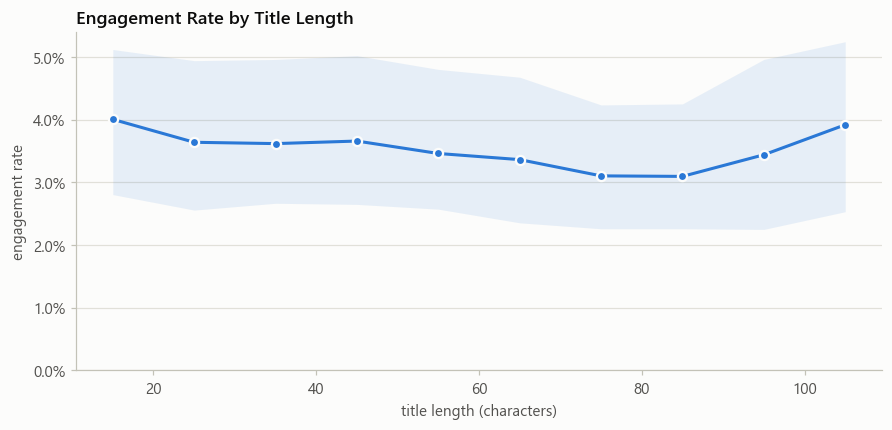

Spearman correlation, title length vs engagement rate: -0.08


,videos,median,q1,q3
title_length_chars,,,,
"[10, 20)",275,0.0400,0.0280,0.0512
"[20, 30)",1034,0.0364,0.0255,0.0494
"[30, 40)",1973,0.0362,0.0266,0.0496
"[40, 50)",2537,0.0366,0.0265,0.0502
"[50, 60)",2128,0.0346,0.0257,0.0480
"[60, 70)",1489,0.0336,0.0235,0.0468
"[70, 80)",894,0.0310,0.0226,0.0423
"[80, 90)",527,0.0309,0.0226,0.0425
"[90, 100)",762,0.0344,0.0225,0.0496


In [22]:
bands = pd.cut(clean.title_length_chars, np.arange(0, 111, 10), right=False)
tl = (clean.groupby(bands, observed=True).engagement_rate
      .agg(videos="size", median="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75)))
tl = tl[tl.videos >= 50]
xs = [band.left + 5 for band in tl.index]
rho = clean.title_length_chars.corr(clean.engagement_rate, method="spearman")

fig, ax = plt.subplots(figsize=(8, 3.8), layout="constrained")
ax.fill_between(xs, tl.q1, tl.q3, color=BLUE, alpha=0.10, linewidth=0)
ax.plot(xs, tl["median"], color=BLUE, linewidth=2, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.yaxis.grid(True)
ax.set_ylim(bottom=0)
ax.set_xlabel("title length (characters)")
ax.set_ylabel("engagement rate")
ax.set_title("Engagement Rate by Title Length")
save(fig, "07_title_length")
print(f"Spearman correlation, title length vs engagement rate: {rho:.2f}")
tl.round(4)

**Reading.** Title length barely matters (ρ = −0.08). The median stays between 3.1% and 4.0% in every
length band, and the spread within a band is far wider than the differences between bands. Title
length isn't worth negotiation time with a creator.

### 6.8 Title and description choices

For each yes/no feature: the share of high-engagement videos **with** the feature minus the share
**without** it, in percentage points. These are raw differences, before accounting for niche or
channel, so they show association, not cause. The model in section 7 separates them out.

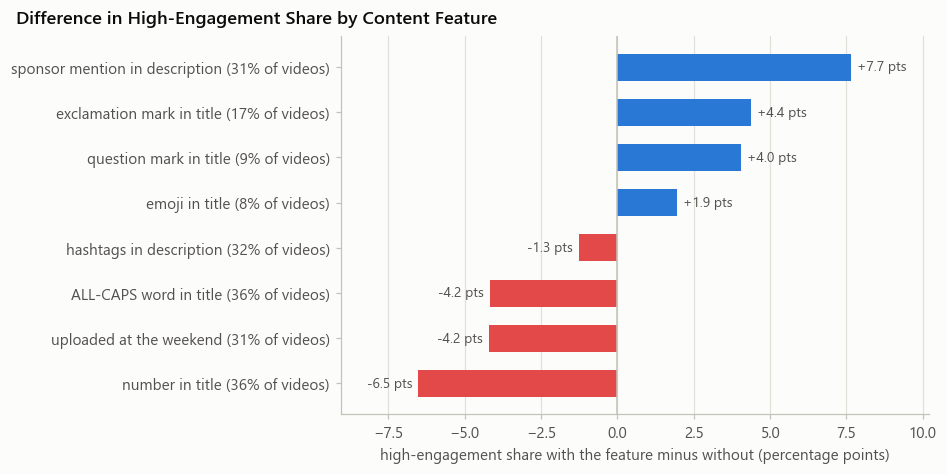

,feature,videos_with,pct_with,high_share_with,high_share_without,difference_pts
0,number in title,4224,0.356,0.260,0.325,-6.516
1,uploaded at the weekend,3669,0.309,0.273,0.315,-4.211
2,ALL-CAPS word in title,4317,0.363,0.275,0.317,-4.164
3,hashtags in description,3838,0.323,0.293,0.306,-1.263
4,emoji in title,960,0.081,0.320,0.300,1.943
5,question mark in title,1024,0.086,0.339,0.298,4.042
6,exclamation mark in title,2038,0.172,0.338,0.294,4.364
7,sponsor mention in description,3633,0.306,0.355,0.279,7.657


In [23]:
flag_df = clean.assign(has_emoji=(clean.emoji_count > 0).astype(int),
                       has_caps=(clean.caps_word_count > 0).astype(int))
flags = {"has_sponsor_mention": "sponsor mention in description", "has_number_in_title": "number in title",
         "has_question_mark": "question mark in title", "has_exclamation": "exclamation mark in title",
         "has_hashtags": "hashtags in description", "is_weekend": "uploaded at the weekend",
         "has_emoji": "emoji in title", "has_caps": "ALL-CAPS word in title"}
rows = []
for col, label in flags.items():
    on, off = flag_df[flag_df[col] == 1].high_engagement, flag_df[flag_df[col] == 0].high_engagement
    rows.append({"feature": label, "videos_with": len(on), "pct_with": len(on) / len(flag_df),
                 "high_share_with": on.mean(), "high_share_without": off.mean(),
                 "difference_pts": (on.mean() - off.mean()) * 100})
lift = pd.DataFrame(rows).sort_values("difference_pts").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 4.2), layout="constrained")
y = np.arange(len(lift))
ax.barh(y, lift.difference_pts, height=0.6, color=[BLUE if v >= 0 else RED for v in lift.difference_pts])
ax.axvline(0, color=AXIS, linewidth=1)
for i, v in enumerate(lift.difference_pts):
    ax.annotate(f"{v:+.1f} pts", (v, i), xytext=(4 if v >= 0 else -4, 0), textcoords="offset points",
                ha="left" if v >= 0 else "right", va="center", color=INK_2, fontsize=9)
ax.set_yticks(y, [f"{f} ({p:.0%} of videos)" for f, p in zip(lift.feature, lift.pct_with)])
ax.margins(x=0.18)
ax.xaxis.grid(True)
ax.set_xlabel("high-engagement share with the feature minus without (percentage points)")
top_row, bottom_row = lift.iloc[-1], lift.iloc[0]
fig.suptitle("Difference in High-Engagement Share by Content Feature", x=0.01, ha="left", fontsize=12, fontweight="semibold", color=INK)
save(fig, "08_feature_differences")
lift.round(3)

**Reading.** Videos that mention a sponsor, discount code or affiliate link are 7.7 points *more* likely
to be high engagement, so disclosed sponsorship does not coincide with weaker response. Numbers in
titles (−6.5), weekend uploads (−4.2) and ALL-CAPS words (−4.2) go with lower engagement. These are
raw associations: established creators with loyal audiences also attract more sponsors.

### 6.9 Target balance

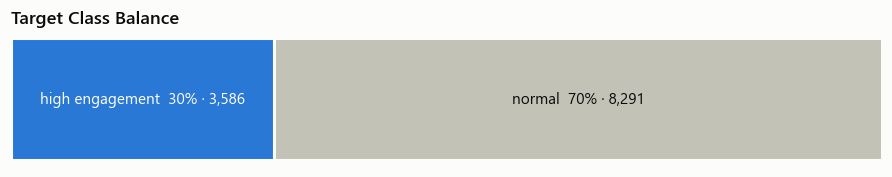

,videos
high_engagement,
normal,8291
high,3586


In [24]:
share_high = clean.high_engagement.mean()
n_high = int(clean.high_engagement.sum())

fig, ax = plt.subplots(figsize=(8, 1.5), layout="constrained")
ax.barh([0], [share_high], height=0.5, color=BLUE, edgecolor=SURFACE, linewidth=2)
ax.barh([0], [1 - share_high], left=[share_high], height=0.5, color=DEEMPH, edgecolor=SURFACE, linewidth=2)
ax.text(share_high / 2, 0, f"high engagement  {share_high:.0%} · {n_high:,}", ha="center", va="center",
        color="white", fontsize=10)
ax.text(share_high + (1 - share_high) / 2, 0, f"normal  {1 - share_high:.0%} · {len(clean) - n_high:,}",
        ha="center", va="center", color=INK, fontsize=10)
ax.set_xlim(0, 1)
ax.axis("off")
ax.set_title("Target Class Balance")
save(fig, "09_target_balance")
clean.high_engagement.value_counts().rename({0: "normal", 1: "high"}).to_frame("videos")

**Reading.** Only 30% of videos are high engagement, so a model that always predicts "normal" would be
70% accurate and useless. The models below are judged on precision, recall, F1 and ROC-AUC, and
trained with balanced class weights.

## 7. Classification models

### 7.1 Set-up

**Two models**, as proposed:
- **Logistic regression**, the interpretable baseline. Its coefficients show the direction of
  each effect.
- **Random forest**, which captures non-linear effects and interactions.

**Class weighting.** Only 30% of videos are "high", so an unweighted model can score 70% accuracy
by always predicting "normal". Both models use `class_weight="balanced"` so missing a high-engagement
video costs as much as a false alarm.

**A status-quo baseline.** A third, deliberately simple model uses **subscriber count alone**. That
is how brands currently choose influencers, so it is the bar the real models must beat.

**Split.** 80% training / 20% test, stratified so both keep the 30/70 balance, `random_state=42`.
Hyperparameters are tuned with 5-fold cross-validation on the training set only; the test set is
touched once, at the end.

In [25]:
import warnings

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, GroupKFold, StratifiedKFold, cross_validate,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

CAT = ["niche", "upload_day_of_week", "upload_daypart_utc"]
NUM = [f for f in feature_cols if f not in CAT]
X, y, groups = clean[NUM + CAT], clean.high_engagement, clean.channelHandle

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"train {len(X_tr):,} videos ({y_tr.mean():.1%} high) · test {len(X_te):,} videos ({y_te.mean():.1%} high)")
print(f"{len(NUM)} numeric + {len(CAT)} categorical predictors")

def pipeline(model, num=NUM, cat=CAT, scale=True, drop=None):
    parts = [("num", StandardScaler() if scale else "passthrough", num)]
    if cat:
        parts.append(("cat", OneHotEncoder(handle_unknown="ignore", drop=drop), cat))
    return Pipeline([("prep", ColumnTransformer(parts)), ("model", model)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
subs_only = pipeline(LogisticRegression(class_weight="balanced", max_iter=1000),
                     num=["log_subscribers"], cat=[])

train 9,501 videos (30.2% high) · test 2,376 videos (30.2% high)
17 numeric + 3 categorical predictors


### 7.2 Tuning with 5-fold cross-validation

In [26]:
LR_GRID = {"model__C": [0.01, 0.1, 1, 10, 100]}
RF_GRID = {"model__min_samples_leaf": [1, 3, 10, 30]}

# drop="first" gives each categorical feature a baseline level, so its coefficients are identifiable
lr_search = GridSearchCV(pipeline(LogisticRegression(class_weight="balanced", max_iter=5000), drop="first"),
                         LR_GRID, cv=cv, scoring="roc_auc")
lr_search.fit(X_tr, y_tr)
best_lr = lr_search.best_estimator_

rf_search = GridSearchCV(pipeline(RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                         n_jobs=-1, random_state=42), scale=False),
                         RF_GRID, cv=cv, scoring="roc_auc")
rf_search.fit(X_tr, y_tr)
best_rf = rf_search.best_estimator_
subs_only_fit = clone(subs_only).fit(X_tr, y_tr)

tuning = pd.DataFrame([
    {"model": "logistic regression", "setting": "C (regularisation)",
     "values tried": LR_GRID["model__C"], "best": lr_search.best_params_["model__C"],
     "cv_roc_auc": lr_search.best_score_},
    {"model": "random forest", "setting": "min_samples_leaf",
     "values tried": RF_GRID["model__min_samples_leaf"], "best": rf_search.best_params_["model__min_samples_leaf"],
     "cv_roc_auc": rf_search.best_score_},
])
tuning.to_csv(ROOT / "report" / "model_tuning.csv", index=False)
tuning.round(3)

,model,setting,values tried,best,cv_roc_auc
0,logistic regression,C (regularisation),"[0.01, 0.1, 1, 10, 100]",0.1,0.897
1,random forest,min_samples_leaf,"[1, 3, 10, 30]",3.0,0.921


### 7.3 Test-set results

How to read the metrics as a marketer:
- **Precision:** of the videos the model flags as high engagement, how many really were. This is
  budget efficiency: low precision means paying for campaigns that underperform.
- **Recall:** of all the high-engagement videos, how many the model found. Low recall means
  missing good opportunities.
- **F1:** a balance of precision and recall.
- **ROC-AUC:** how well the model ranks videos from most to least likely to engage, across every
  possible cut-off. 0.5 is a coin toss and 1.0 is perfect.

In [27]:
def test_scores(name, model):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {"model": name, "accuracy": accuracy_score(y_te, pred), "precision": precision_score(y_te, pred),
            "recall": recall_score(y_te, pred), "f1": f1_score(y_te, pred), "roc_auc": roc_auc_score(y_te, proba)}

models = {"subscriber count only": subs_only_fit, "logistic regression": best_lr, "random forest": best_rf}
test_table = pd.DataFrame([test_scores(n, m) for n, m in models.items()]).set_index("model")
test_table.to_csv(ROOT / "report" / "model_test_metrics.csv")
print(f"for reference, always predicting 'normal' scores {1 - y_te.mean():.1%} accuracy and 0 recall")
test_table.round(3)

for reference, always predicting 'normal' scores 69.8% accuracy and 0 recall


,accuracy,precision,recall,f1,roc_auc
model,,,,,
subscriber count only,0.559,0.332,0.453,0.383,0.569
logistic regression,0.814,0.647,0.842,0.732,0.897
random forest,0.847,0.719,0.808,0.761,0.919


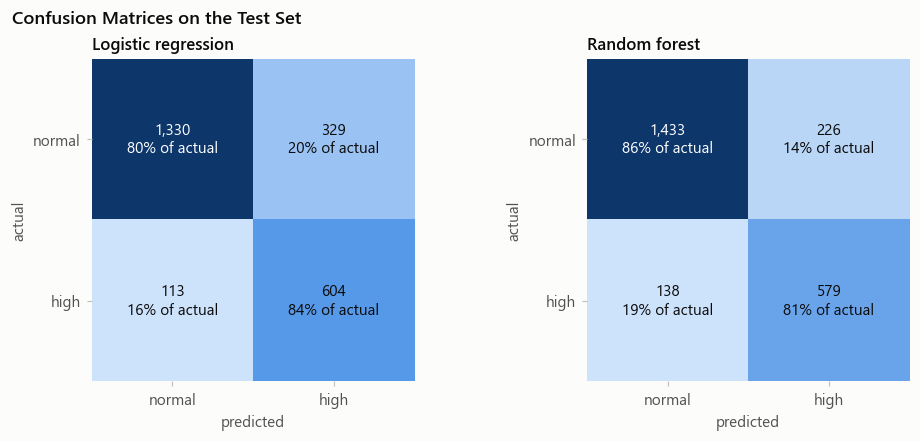

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.9), layout="constrained")
for ax, (name, model) in zip(axes, [("Logistic regression", best_lr), ("Random forest", best_rf)]):
    cm = confusion_matrix(y_te, model.predict(X_te))
    ax.imshow(cm, cmap=SEQUENTIAL)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n{cm[i, j] / cm[i].sum():.0%} of actual", ha="center", va="center",
                    fontsize=10, color="white" if cm[i, j] > cm.max() * 0.55 else INK)
    ax.set_xticks([0, 1], ["normal", "high"])
    ax.set_yticks([0, 1], ["normal", "high"])
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
    ax.set_title(name, fontsize=11)
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle("Confusion Matrices on the Test Set", x=0.01, ha="left", fontsize=12, fontweight="semibold", color=INK)
save(fig, "10_confusion_matrices")

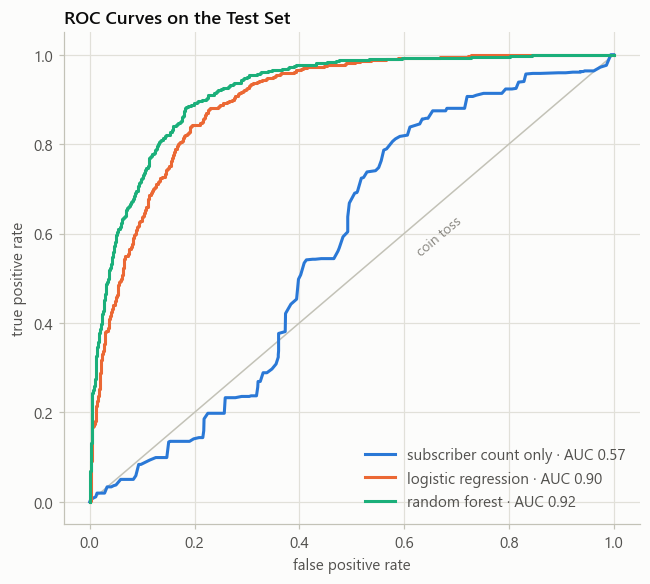

In [29]:
fig, ax = plt.subplots(figsize=(5.8, 5.2), layout="constrained")
ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1)
ax.text(0.62, 0.55, "coin toss", color=MUTED, fontsize=9, rotation=40)
for (name, model), colour in zip(models.items(), [BLUE, ORANGE, "#1baf7a"]):  # palette slots 1-3
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax.plot(fpr, tpr, color=colour, linewidth=2, label=f"{name} · AUC {roc_auc_score(y_te, proba):.2f}")
ax.legend(loc="lower right")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.grid(True)
ax.set_title("ROC Curves on the Test Set")
save(fig, "11_roc_curves")

**Reading.** The random forest is the strongest model (ROC-AUC 0.92, F1 0.76). When it flags a video as
high engagement it is right 72% of the time, 2.4× the 30% base rate, and it finds 81% of all
high-engagement videos. Logistic regression is close behind (AUC 0.90), with higher recall (84%) but
more false alarms (precision 65%). The subscriber-count model scores 0.57, barely better than a coin
toss, and its picks are right 33% of the time, almost exactly the base rate. **Choosing creators by
subscriber count alone is close to choosing at random.**

### 7.4 Would it work on creators the model has never seen?

The random 80/20 split puts videos from the **same channel** in both training and test. A model
can then partly recognise the channel, for example from its exact subscriber count, rather than
learning what drives engagement. A brand evaluating a *new* creator doesn't get that advantage.

So every model is re-scored two ways:
- **random 5-fold:** the same kind of split as above
- **unseen channels 5-fold:** all of a channel's videos sit in the same fold, so each test fold
  contains only creators the model never trained on

A fourth model, random forest **without** the channel-history feature, shows how much of the
performance depends on that feature.

In [30]:
rf_no_history = pipeline(clone(best_rf.named_steps["model"]),
                         num=[c for c in NUM if c != "channel_prior_engagement"], scale=False)
candidates = {"subscriber count only": subs_only, "logistic regression": best_lr,
              "random forest": best_rf, "random forest, no channel history": rf_no_history}
splits = {"random 5-fold": (cv, None), "unseen channels 5-fold": (GroupKFold(n_splits=5), groups)}

rows = []
for mname, est in candidates.items():
    for sname, (splitter, grp) in splits.items():
        s = cross_validate(clone(est), X, y, cv=splitter, groups=grp, scoring=["roc_auc", "f1"])
        rows.append({"model": mname, "split": sname,
                     "roc_auc": s["test_roc_auc"].mean(), "roc_auc_sd": s["test_roc_auc"].std(),
                     "f1": s["test_f1"].mean()})
cv_long = pd.DataFrame(rows)
cv_long.to_csv(ROOT / "report" / "model_cv_comparison.csv", index=False)
cv_table = cv_long.pivot(index="model", columns="split", values="roc_auc").reindex(candidates)
cv_table["drop on unseen channels"] = cv_table["random 5-fold"] - cv_table["unseen channels 5-fold"]
cv_table.round(3)

split,random 5-fold,unseen channels 5-fold,drop on unseen channels
model,,,
subscriber count only,0.562,0.554,0.008
logistic regression,0.898,0.885,0.013
random forest,0.923,0.879,0.044
"random forest, no channel history",0.922,0.635,0.287


**Reading.** Both full models hold up on creators they have never seen: logistic regression 0.885 and
random forest 0.879, down only 0.01–0.04. The random forest *without* channel history tells the real
story. It scores 0.922 on a random split but only 0.635 on unseen creators, because it had been
recognising channels by their exact subscriber and upload counts instead of learning what drives
engagement. Channel history is the feature that carries over to new creators.

### 7.5 What drives the predictions

**Permutation importance** (random forest, test set): shuffle one feature at a time and measure
how much ROC-AUC falls. A large fall means the model depends on that feature. This is measured on
data the model never saw, which makes it more trustworthy than the forest's built-in importance
scores (those favour features with many distinct values).

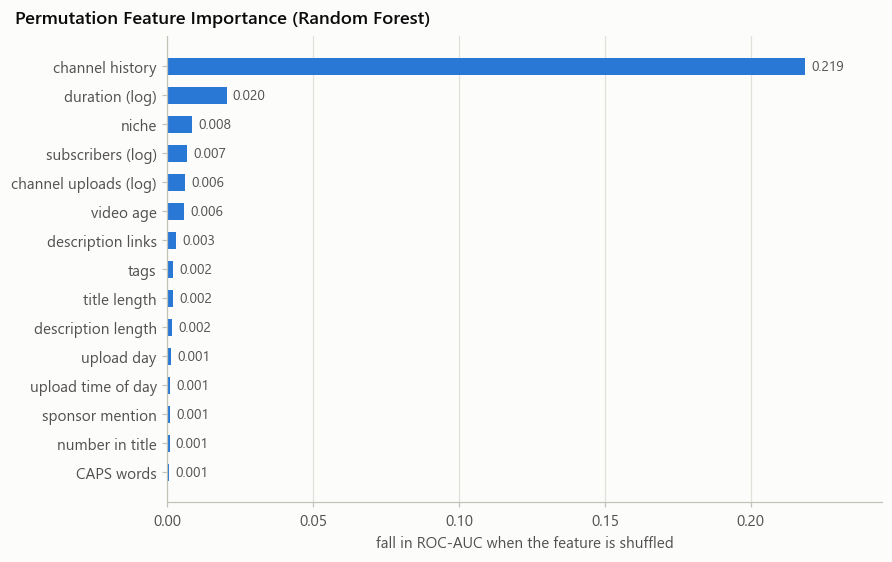

,label,auc_drop,sd
0,channel history,0.2187,0.0063
1,duration (log),0.0203,0.0022
2,niche,0.0085,0.0009
3,subscribers (log),0.0069,0.0016
4,channel uploads (log),0.0061,0.0009
5,video age,0.0057,0.0008
6,description links,0.0030,0.0007
7,tags,0.0020,0.0004
8,title length,0.0019,0.0008
9,description length,0.0017,0.0009


In [31]:
perm = permutation_importance(best_rf, X_te, y_te, scoring="roc_auc", n_repeats=10, random_state=42)
importance = (pd.DataFrame({"feature": X_te.columns, "auc_drop": perm.importances_mean,
                            "sd": perm.importances_std})
              .assign(label=lambda d: d.feature.map(LABELS))
              .sort_values("auc_drop", ascending=False).reset_index(drop=True))
importance.to_csv(ROOT / "report" / "feature_importance_permutation.csv", index=False)

top = importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
ax.barh(np.arange(len(top)), top.auc_drop, height=0.6, color=BLUE)
for i, v in enumerate(top.auc_drop):
    ax.annotate(f"{v:.3f}", (max(v, 0), i), xytext=(4, 0), textcoords="offset points",
                va="center", color=INK_2, fontsize=9)
ax.set_yticks(np.arange(len(top)), top.label)
ax.margins(x=0.12)
ax.xaxis.grid(True)
ax.set_xlabel("fall in ROC-AUC when the feature is shuffled")
first, second = importance.iloc[0], importance.iloc[1]
fig.suptitle("Permutation Feature Importance (Random Forest)", x=0.01, ha="left", fontsize=12, fontweight="semibold", color=INK)
save(fig, "12_feature_importance")
importance[["label", "auc_drop", "sd"]].round(4)

**Reading.** Shuffling channel history cuts ROC-AUC by 0.22, about 11 times more than duration, the next
feature (0.020). Niche, subscriber count and channel size follow. Title features contribute almost
nothing (each below 0.002).

**Logistic regression coefficients.** Numeric features are standardised, so each coefficient is
the change in log-odds of high engagement for a one-standard-deviation increase. Positive (blue)
raises the odds and negative (red) lowers them. Each categorical feature has one baseline level
(its first value alphabetically), and its coefficients compare the other levels with that baseline,
holding everything else, including channel history, constant.

baseline levels: {'niche': 'beauty', 'upload day': 'Friday', 'upload time of day': '00-05'}


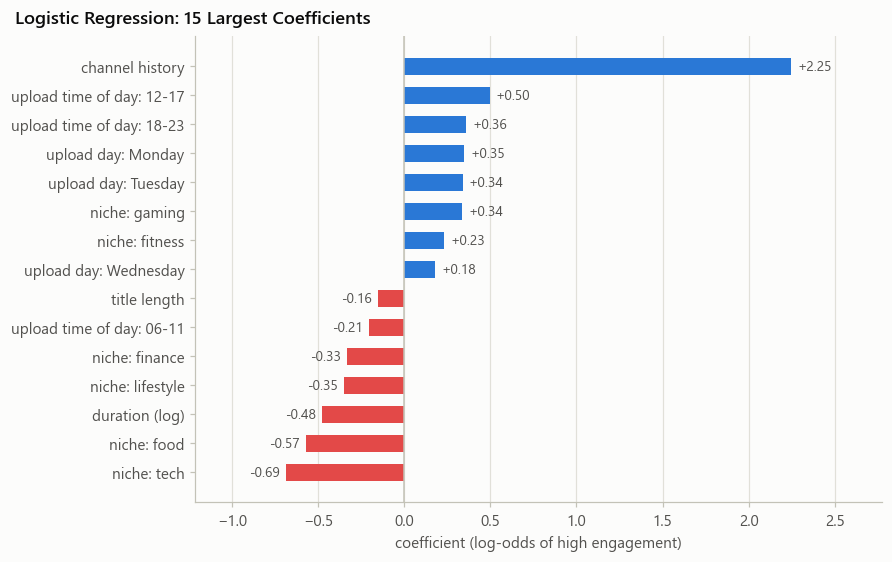

,coefficient,odds_ratio
channel history,2.246,9.452
niche: tech,-0.687,0.503
niche: food,-0.574,0.563
upload time of day: 12-17,0.495,1.641
duration (log),-0.477,0.621
upload time of day: 18-23,0.358,1.430
niche: lifestyle,-0.351,0.704
upload day: Monday,0.346,1.414
upload day: Tuesday,0.338,1.403
niche: gaming,0.335,1.398


In [32]:
names = best_lr.named_steps["prep"].get_feature_names_out()
coef = pd.Series(best_lr.named_steps["model"].coef_[0], index=names)
encoder = best_lr.named_steps["prep"].named_transformers_["cat"]
print("baseline levels:", {LABELS[c]: levels[0] for c, levels in zip(CAT, encoder.categories_)})

def pretty(name):
    kind, rest = name.split("__", 1)
    if kind == "num":
        return LABELS.get(rest, rest)
    for c in CAT:
        if rest.startswith(c + "_"):
            return f"{LABELS[c]}: {rest[len(c) + 1:]}"
    return rest

coefs = (coef.rename(pretty).to_frame("coefficient")
         .assign(odds_ratio=lambda d: np.exp(d.coefficient))
         .sort_values("coefficient", key=abs, ascending=False))
coefs.to_csv(ROOT / "report" / "logistic_coefficients.csv")

top = coefs.head(15).sort_values("coefficient")
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
ax.barh(np.arange(len(top)), top.coefficient, height=0.6,
        color=[BLUE if v >= 0 else RED for v in top.coefficient])
ax.axvline(0, color=AXIS, linewidth=1)
for i, v in enumerate(top.coefficient):
    ax.annotate(f"{v:+.2f}", (v, i), xytext=(4 if v >= 0 else -4, 0), textcoords="offset points",
                ha="left" if v >= 0 else "right", va="center", color=INK_2, fontsize=9)
ax.set_yticks(np.arange(len(top)), top.index)
ax.margins(x=0.18)
ax.xaxis.grid(True)
ax.set_xlabel("coefficient (log-odds of high engagement)")
fig.suptitle("Logistic Regression: 15 Largest Coefficients", x=0.01, ha="left", fontsize=12, fontweight="semibold", color=INK)
save(fig, "13_logistic_coefficients")
coefs.head(20).round(3)

**Reading.** Holding everything else constant, a one-standard-deviation rise in a channel's past
engagement multiplies the odds of a high-engagement video by 9.5. Longer videos lower the odds (×0.62 per
standard deviation of log duration), and uploading between 12:00 and 17:59 UTC raises them (×1.64
against 00:00–05:59). Tech and food channels have about half the odds of beauty channels with the same
history. Subscriber count doesn't appear among the 20 largest effects: once history is known it adds
almost nothing.

## 8. Business insights and recommendations

| # | Insight | Evidence | Recommendation |
| --- | --- | --- | --- |
| 1 | Subscriber count is a poor way to choose creators | Subscriber-only model: ROC-AUC 0.57, picks right 33% of the time (base rate 30%); 5M+ channels have the lowest high-engagement share (17%) | Stop shortlisting by subscribers. Use subscriber count to size reach, not to predict response |
| 2 | Past engagement is the strongest predictor | ρ = 0.77; about 11× more important than any other feature; without it the model falls to 0.635 on new creators | Before signing, calculate the creator's average (likes + comments) / views over their last 5+ long-form videos and shortlist those above 4.5% |
| 3 | Mid-size creators engage best | 42% high at 1M–5M vs 17% at 5M+ | Put engagement-led budgets into 1M–5M creators; use 5M+ creators for awareness and negotiate on cost per engagement |
| 4 | Niche sets the baseline | Fashion 60%, lifestyle 53%, beauty 45% high vs fitness 13%, gaming 20% | Set engagement targets per niche |
| 5 | Mid-length videos and afternoon–evening (UTC) uploads do best | 8–15 min: 39% high vs 18% at 30+ min; Friday/Saturday 24% vs 34–35% Monday/Wednesday/Thursday; 12:00–23:59 UTC 32–35% vs 17–18% | Brief integrations into 8–15 minute videos; avoid Friday and Saturday releases; publish between 12:00 and 23:59 UTC |
| 6 | Sponsorship doesn't coincide with weaker response; title cosmetics barely matter | Sponsor mention +7.7 pts; each title feature below 0.002 AUC importance | Keep sponsorships disclosed; spend creative effort on format and timing, not titles, emoji or capitals |

**Using the model as a screen.** On the test set, 72% of the videos the random forest flagged were high
engagement, against 30% when picking at random and 33% when picking by subscriber count. A brand funding
only flagged placements would land about 2.4× as many high-engagement placements as random selection.

### Limitations

- **Sample.** Channels were hand-picked or found by search, not randomly sampled. Results describe these
  143 English-language channels, not YouTube as a whole.
- **Association, not causation.** Differences such as the sponsor-mention effect may reflect which
  creators use a feature rather than the feature's effect.
- **Engagement is not sales.** Likes and comments are a proxy for response; the data has no clicks,
  conversions or campaign spend.
- **Snapshot and proxies.** Statistics were captured on 10–11 Sep 2026. Shorts are identified by duration,
  sponsorship by description keywords, and upload time is in UTC.
- **History required.** Channel history needs at least 5 earlier videos, so brand-new creators can't be
  scored this way.